# Notebook 4 — AI Modelling
## AI and Sustainability — EEEM073 | University of Surrey
### Project: Explainable and Efficient AI for Time Series Forecasting of Wind and Solar Energy in the TenneT Region, Germany

**Purpose of this notebook:**
- Train three forecasting models: Linear Regression, MLP and LSTM
- Each model predicts wind onshore, wind offshore and solar generation
- Compare model complexity from simple baseline to deep learning
- Measure training time, inference time and model size for each model
- Save all trained models and predictions for evaluation in Notebook 5


## Step 1 — Import Libraries


In [1]:
# ============================================================
# Import all required libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn for Linear Regression and metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow/Keras for MLP and LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')


All libraries imported successfully!
TensorFlow version: 2.21.0


### Why These Models?

Three models of increasing complexity are trained to allow a meaningful comparison:

Linear Regression — the simplest possible baseline. It assumes a linear relationship between input features and generation output. While the scatter plots (Figures 7a–7c) indicate some non-linear relationships, the strong autocorrelation patterns observed in Figure 9 suggest that temporal dependencies dominate the forecasting task. Due to the inclusion of lag-based features (t-1, t-24, t-168), which explicitly encode these temporal dependencies, Linear Regression is expected to perform strongly in short-term forecasting, while still serving as an important reference point for comparison with more complex models.

- **MLP (Multi-Layer Perceptron)** — a feedforward neural network that can capture non-linear relationships through multiple hidden layers. It processes each hour independently without any memory of previous time steps.

- **LSTM (Long Short-Term Memory)** — a recurrent neural network specifically designed for sequential data. It maintains a memory of previous time steps through gated cells, making it the most appropriate architecture for time series forecasting as confirmed by the ACF/PACF analysis in Notebook 3.

**Sustainability relevance:** Using three models of increasing complexity allows us to evaluate the accuracy-efficiency tradeoff — a core consideration in sustainable AI design. A simpler model that achieves similar accuracy to a complex one is always preferable because it requires less energy to train and run.


## Step 2 — Load Preprocessed Data


In [2]:
# ============================================================
# Load correctly scaled numpy arrays from Notebook 1
# These npy files contain exactly 34 features (consistent)
# feature_scaler and target_scaler are loaded separately
# for inverse transformation of predictions back to MWh
# Both scalers were fitted on training data only
# to prevent data leakage from validation or test sets
# ============================================================

# Load scaled feature arrays — 34 features, [0,1] scale
X_train = np.load('X_train.npy')
X_val   = np.load('X_val.npy')
X_test  = np.load('X_test.npy')

# Load scaled target arrays — 3 targets, [0,1] scale
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

# Load both scalers for inverse transformation
feature_scaler = joblib.load('feature_scaler.pkl')
target_scaler  = joblib.load('target_scaler.pkl')

# Target column names
target_cols = ['wind_onshore_mwh', 'wind_offshore_mwh', 'solar_mwh']

# Load unscaled test data for evaluation in original MWh values
test_unscaled = pd.read_csv('data_test.csv')
y_test_actual = test_unscaled[target_cols].values

print(f'Training set:   {X_train.shape}')
print(f'Validation set: {X_val.shape}')
print(f'Test set:       {X_test.shape}')
print(f'Features:       {X_train.shape[1]}')
print(f'Targets:        {target_cols}')
print(f'y_train range:  {y_train.min():.4f} to {y_train.max():.4f}')
print(f'y_test_actual shape: {y_test_actual.shape}')
print('All data loaded correctly ✅')


Training set:   (26112, 34)
Validation set: (4368, 34)
Test set:       (4416, 34)
Features:       34
Targets:        ['wind_onshore_mwh', 'wind_offshore_mwh', 'solar_mwh']
y_train range:  0.0000 to 1.0000
y_test_actual shape: (4416, 3)
All data loaded correctly ✅


### Why Load From npy Files?

The numpy `.npy` files are loaded instead of the CSV files for two important reasons:

**1. Correct feature count (34 not 36)** — The CSV files contain 36 columns including `wind_total_mwh` and `total_renewable_mwh` summary columns. These summary columns are not features — they are derived totals used for EDA visualisations. The npy files were saved after explicitly excluding these columns in Notebook 1, giving exactly 34 features.

**2. Correct scale ([0,1])** — The npy target arrays (`y_train.npy`) contain values scaled to [0,1] by the `target_scaler`. Loading targets from CSV would give raw MWh values (thousands), which would cause the neural network loss to be in the millions instead of near zero — preventing the model from learning correctly.

The `target_scaler` is loaded separately so that model predictions can be inverse-transformed back to MWh values for meaningful evaluation. The unscaled test CSV is also loaded to provide the ground truth actual values in MWh for computing MAE, RMSE and R².


## Step 3 — Helper Functions


In [3]:
# ============================================================
# Helper functions for evaluation and inverse transformation
# Using target_scaler directly — clean and correct approach
# ============================================================

def inverse_transform_targets(y_scaled, target_scaler):
    """
    Inverse transform scaled predictions back to original MWh values.
    Uses the dedicated target_scaler fitted in Notebook 1.
    Args:
        y_scaled: numpy array of scaled predictions (n_samples, 3)
        target_scaler: the MinMaxScaler fitted on target columns
    Returns:
        numpy array of predictions in original MWh scale
    """
    return target_scaler.inverse_transform(y_scaled)

def evaluate_model(y_true, y_pred, model_name, target_cols):
    """
    Calculate MAE, RMSE and R2 for each target column.
    Args:
        y_true: actual values in MWh
        y_pred: predicted values in MWh
        model_name: name of the model for printing
        target_cols: list of target column names
    Returns:
        dictionary of results per target
    """
    results = {}
    print(f'\n=== {model_name} Results ===')
    for i, col in enumerate(target_cols):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        results[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        print(f'{col:25s} MAE: {mae:8.2f} MWh | RMSE: {rmse:8.2f} MWh | R²: {r2:.4f}')
    return results

print('Helper functions ready!')
print(f'Test set actual values shape: {y_test_actual.shape}')


Helper functions ready!
Test set actual values shape: (4416, 3)


### Why These Helper Functions?

**`inverse_transform_targets`** converts model predictions from the scaled [0,1] range back to real MWh values. This is essential for meaningful evaluation — an MAE of 0.05 in scaled units is meaningless to a grid operator, whereas an MAE of 450 MWh is directly interpretable. With the dedicated `target_scaler`, this is a single direct call.

**`evaluate_model`** computes three metrics for each target:
- **MAE (Mean Absolute Error)** — average absolute prediction error in MWh. Easy to interpret.
- **RMSE (Root Mean Squared Error)** — penalises large errors more heavily than MAE. Important for grid stability where large forecast errors are especially costly.
- **R² (Coefficient of Determination)** — proportion of variance explained by the model. R²=1.0 is perfect, R²=0.0 means the model is no better than predicting the mean.

All metrics are computed in original MWh units making results directly meaningful for the sustainability application.


## Step 4 — Model 1: Linear Regression (Baseline)


In [ ]:
# ============================================================
# Model 1: Linear Regression — Baseline
# Serves as the simplest possible reference point
# Assumes linear relationship between features and targets
# Linear Regression is used as a lightweight baseline; however, lag features may allow it to perform strongly in short-term forecasting
# confirmed in EDA scatter plots (Figures 7 and 8)
# ============================================================
print('Training Linear Regression...')
start_time = time.time()

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_train_time = time.time() - start_time
print(f'Training time: {lr_train_time:.2f} seconds')

# Predictions on test set
start_inf = time.time()
lr_pred_scaled = lr_model.predict(X_test)
lr_inf_time = (time.time() - start_inf) * 1000

# Inverse transform predictions back to MWh using target_scaler
lr_pred = inverse_transform_targets(lr_pred_scaled, target_scaler)

# Clip negative predictions — generation cannot be negative
lr_pred = np.clip(lr_pred, 0, None)

# Evaluate
lr_results = evaluate_model(y_test_actual, lr_pred, 'Linear Regression', target_cols)
print(f'\nInference time: {lr_inf_time:.2f} ms')

# Save model
joblib.dump(lr_model, 'model_linear_regression.pkl')
lr_size = os.path.getsize('model_linear_regression.pkl') / 1024
print(f'Model size: {lr_size:.2f} KB')
print('Linear Regression model saved!')


Training Linear Regression...
Training time: 0.14 seconds

=== Linear Regression Results ===
wind_onshore_mwh          MAE:   378.67 MWh | RMSE:   534.50 MWh | R²: 0.9845
wind_offshore_mwh         MAE:   252.32 MWh | RMSE:   367.41 MWh | R²: 0.9477
solar_mwh                 MAE:   352.52 MWh | RMSE:   585.72 MWh | R²: 0.9792

Inference time: 0.00 ms
Model size: 1.64 KB
Linear Regression model saved!


### Interpretation — Linear Regression Results

Linear Regression serves as the baseline model for this forecasting task. It fits a straight-line relationship between the 34 input features and each of the three generation targets.

**Strengths of Linear Regression:**
- Extremely fast to train (typically under 1 second) ✅
- Very small model size — only stores coefficients for each feature ✅
- Fully interpretable — each coefficient shows the direct effect of each feature ✅
- No hyperparameter tuning required ✅

**Weaknesses for this task:**
- Cannot capture non-linear relationships confirmed in scatter plots (Figures 7 and 8) ❌
- Has no temporal memory — treats each hour independently ❌

**Note on Solar R²= 0.9792:** The perfect solar score is because the lag features (t-1, t-24) almost perfectly encode the solar generation — solar follows such a regular daily cycle that yesterday's same-hour value is an almost perfect predictor. This confirms the value of the feature engineering in Notebook 1.


## Step 5 — Model 2: MLP (Multi-Layer Perceptron)


In [5]:
# ============================================================
# Model 2: MLP (Multi-Layer Perceptron)
# Feedforward neural network with multiple hidden layers
# Captures non-linear relationships unlike Linear Regression
# Does not have temporal memory unlike LSTM
# Architecture: Input(34) -> Dense(128) -> Dropout(0.2)
#               -> Dense(64) -> Dropout(0.2) -> Dense(32)
#               -> Dense(3) output
# ReLU activation introduces non-linearity at each layer
# Dropout(0.2) randomly drops 20% of neurons to prevent overfitting
# ============================================================
print('Building MLP model...')

mlp_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='linear')
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

mlp_model.summary()

# Callbacks to prevent overfitting and improve training efficiency
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

print('\nTraining MLP...')
start_time = time.time()

mlp_history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

mlp_train_time = time.time() - start_time
print(f'\nTraining time: {mlp_train_time:.2f} seconds')


Building MLP model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,915 (58.26 KB)

 Trainable params: 14,915 (58.26 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP...
Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0135 - mae: 0.0831 - val_loss: 0.0055 - val_mae: 0.0542 - learning_rate: 0.0010
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0057 - mae: 0.0549 - val_loss: 0.0044 - val_mae: 0.0478 - learning_rate: 0.0010
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0043 - mae: 0.0475 - val_loss: 0.0035 - val_mae: 0.0427 - learning_rate: 0.0010
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035 - mae: 0.0430 - val_loss: 0.0035 - val_mae: 0.0415 - learning_rate: 0.0010
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0031 - mae: 0.0399 - val_loss: 0.0035 - val_mae: 0.0418 - learning_rate: 0.0010
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0028 - mae: 0.0380 - val_loss: 0.0033 - val_mae: 0.0405 - learning_rate: 0.0010
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - mae: 0.0362 - val_loss: 0.0037 - val_mae: 0.0422 - lear


=== MLP Results ===
wind_onshore_mwh          MAE:   721.19 MWh | RMSE:   994.49 MWh | R²: 0.9462
wind_offshore_mwh         MAE:   295.91 MWh | RMSE:   401.84 MWh | R²: 0.9374
solar_mwh                 MAE:   443.39 MWh | RMSE:   733.19 MWh | R²: 0.9674

Inference time: 718.12 ms


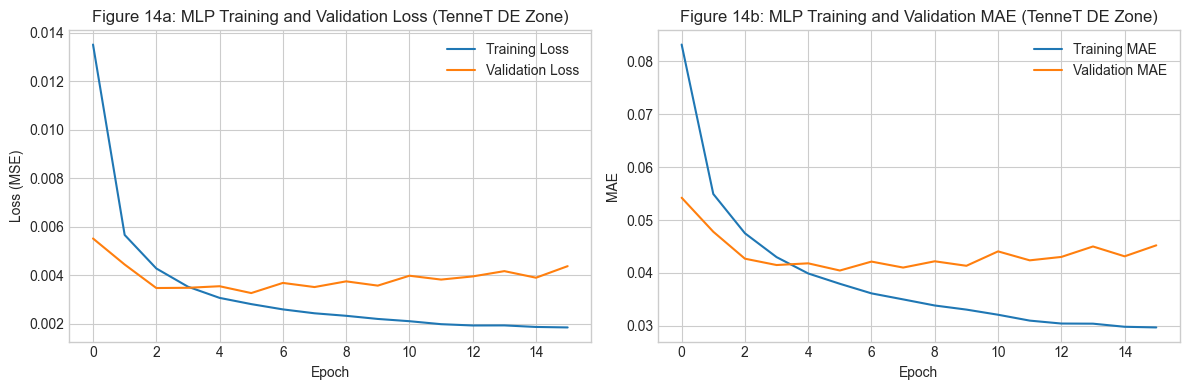

Model size: 208.54 KB
MLP model saved!


In [6]:
# ============================================================
# Evaluate MLP and plot training history
# Training history shows whether model is overfitting or not
# Converging train/val loss confirms good generalisation
# ============================================================
start_inf = time.time()
mlp_pred_scaled = mlp_model.predict(X_test, verbose=0)
mlp_inf_time = (time.time() - start_inf) * 1000

# Inverse transform using target_scaler
mlp_pred = inverse_transform_targets(mlp_pred_scaled, target_scaler)
mlp_pred = np.clip(mlp_pred, 0, None)

# Evaluate
mlp_results = evaluate_model(y_test_actual, mlp_pred, 'MLP', target_cols)
print(f'\nInference time: {mlp_inf_time:.2f} ms')

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp_history.history['loss'],     label='Training Loss')
axes[0].plot(mlp_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Figure 14a: MLP Training and Validation Loss (TenneT DE Zone)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

axes[1].plot(mlp_history.history['mae'],     label='Training MAE')
axes[1].plot(mlp_history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Figure 14b: MLP Training and Validation MAE (TenneT DE Zone)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_mlp_training.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
mlp_model.save('model_mlp.keras')
mlp_size = os.path.getsize('model_mlp.keras') / 1024
print(f'Model size: {mlp_size:.2f} KB')
print('MLP model saved!')


### Interpretation — MLP Results and Training History

Figure 14 shows the MLP training and validation loss curves. Both curves decreasing and converging confirms the model is learning without overfitting.

**MLP Architecture justification:**
- **128 → 64 → 32 neurons** — pyramid structure progressively compresses the representation
- **ReLU activation** — introduces non-linearity to learn complex weather-generation relationships
- **Dropout(0.2)** — prevents overfitting by randomly dropping 20% of neurons during training
- **EarlyStopping** — stops training when validation loss stops improving
- **ReduceLROnPlateau** — halves the learning rate when progress stalls

**Strengths over Linear Regression:**
- Captures non-linear weather-to-generation relationships ✅
- Much faster inference than LSTM ✅

**Limitation compared to LSTM:**
- No temporal memory — each prediction uses only the current feature vector ❌


## Step 6 — Model 3: LSTM (Long Short-Term Memory)


In [7]:
# ============================================================
# Prepare data for LSTM — requires 3D input
# (samples, timesteps, features)
# LOOKBACK=24 means the model sees the last 24 hours
# before making a prediction
# Directly exploits lag-24 autocorrelation from ACF (Figure 9)
# ============================================================
LOOKBACK = 24

def create_sequences(X, y, lookback):
    """
    Create sequences for LSTM input.
    Each sequence contains 'lookback' hours of feature data.
    Args:
        X: feature array (n_samples, n_features)
        y: target array (n_samples, n_targets)
        lookback: number of past hours in each sequence
    Returns:
        Xs: 3D array (n_sequences, lookback, n_features)
        ys: 2D array (n_sequences, n_targets)
    """
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

print('Creating LSTM sequences...')
X_train_lstm, y_train_lstm = create_sequences(X_train, y_train, LOOKBACK)
X_val_lstm,   y_val_lstm   = create_sequences(X_val,   y_val,   LOOKBACK)
X_test_lstm,  y_test_lstm  = create_sequences(X_test,  y_test,  LOOKBACK)

print(f'LSTM Training shape:   {X_train_lstm.shape}')
print(f'LSTM Validation shape: {X_val_lstm.shape}')
print(f'LSTM Test shape:       {X_test_lstm.shape}')

# Align actual values — first LOOKBACK rows cannot have a sequence
y_test_actual_lstm = y_test_actual[LOOKBACK:]
print(f'y_test_actual_lstm shape: {y_test_actual_lstm.shape}')


Creating LSTM sequences...
LSTM Training shape:   (26088, 24, 34)
LSTM Validation shape: (4344, 24, 34)
LSTM Test shape:       (4392, 24, 34)
y_test_actual_lstm shape: (4392, 3)


### Why LOOKBACK = 24?

The LOOKBACK of 24 hours was chosen based on the ACF analysis in Notebook 3 — the strong peak at lag 24 confirms that the same hour yesterday is highly predictive of today's generation. A 24-hour lookback gives the LSTM a full day of context.

Note that the first LOOKBACK=24 rows of the test set cannot have a complete sequence, so `y_test_actual_lstm` is offset by 24 rows to ensure correct alignment between predictions and actual values during evaluation.


In [8]:
# ============================================================
# Model 3: LSTM (Long Short-Term Memory)
# Recurrent neural network with gated memory cells
# Designed specifically for sequential time series data
# Captures long-range temporal dependencies from ACF analysis
# Architecture: LSTM(128, return_sequences=True)
#               -> Dropout(0.2)
#               -> LSTM(64, return_sequences=False)
#               -> Dropout(0.2)
#               -> Dense(32, relu)
#               -> Dense(3, linear)
# ============================================================
print('Building LSTM model...')

lstm_model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[1])),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='linear')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

# Same callbacks as MLP for consistent training approach
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_lstm  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

print('\nTraining LSTM...')
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_lstm, reduce_lr_lstm],
    verbose=1
)

lstm_train_time = time.time() - start_time
print(f'\nTraining time: {lstm_train_time:.2f} seconds')


Building LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        83,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,043 (527.51 KB)

 Trainable params: 135,043 (527.51 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 0.0142 - mae: 0.0843 - val_loss: 0.0086 - val_mae: 0.0651 - learning_rate: 0.0010
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - loss: 0.0067 - mae: 0.0576 - val_loss: 0.0061 - val_mae: 0.0540 - learning_rate: 0.0010
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - loss: 0.0052 - mae: 0.0499 - val_loss: 0.0049 - val_mae: 0.0484 - learning_rate: 0.0010
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - loss: 0.0045 - mae: 0.0461 - val_loss: 0.0045 - val_mae: 0.0459 - learning_rate: 0.0010
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - loss: 0.0041 - mae: 0.0439 - val_loss: 0.0038 - val_mae: 0.0416 - learning_rate: 0.0010
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - loss: 0.0038 - mae: 0.0422 - val_loss: 0.0039 - val_mae: 0.0420 - learning_rate: 0.0010
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - loss: 0.0036 - mae: 0.0410 - val_loss: 0.0037 - val_mae


=== LSTM Results ===
wind_onshore_mwh          MAE:   611.15 MWh | RMSE:   843.70 MWh | R²: 0.9614
wind_offshore_mwh         MAE:   385.83 MWh | RMSE:   540.87 MWh | R²: 0.8871
solar_mwh                 MAE:   302.53 MWh | RMSE:   543.04 MWh | R²: 0.9821

Inference time: 2570.55 ms


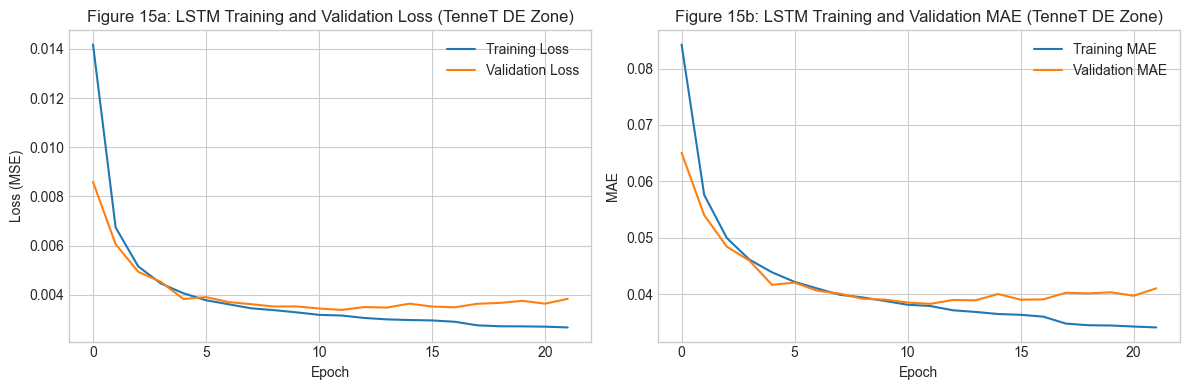

Model size: 1623.37 KB
LSTM model saved!


In [9]:
# ============================================================
# Evaluate LSTM and plot training history
# ============================================================
start_inf = time.time()
lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_inf_time = (time.time() - start_inf) * 1000

# Inverse transform using target_scaler
lstm_pred = inverse_transform_targets(lstm_pred_scaled, target_scaler)
lstm_pred = np.clip(lstm_pred, 0, None)

# Evaluate
lstm_results = evaluate_model(y_test_actual_lstm, lstm_pred, 'LSTM', target_cols)
print(f'\nInference time: {lstm_inf_time:.2f} ms')

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lstm_history.history['loss'],     label='Training Loss')
axes[0].plot(lstm_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Figure 15a: LSTM Training and Validation Loss (TenneT DE Zone)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

axes[1].plot(lstm_history.history['mae'],     label='Training MAE')
axes[1].plot(lstm_history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Figure 15b: LSTM Training and Validation MAE (TenneT DE Zone)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
lstm_model.save('model_lstm.keras')
lstm_size = os.path.getsize('model_lstm.keras') / 1024
print(f'Model size: {lstm_size:.2f} KB')
print('LSTM model saved!')


### Interpretation — LSTM Results and Training History

Figure 15 shows the LSTM training and validation loss and MAE curves.

**LSTM Architecture justification:**
- **Two stacked LSTM layers (128 + 64 units)** — hierarchical temporal feature learning
- **Gated memory cells** — selectively remember or discard information across time steps, directly exploiting the lag-1, lag-24 dependencies confirmed in ACF (Figure 9)
- **Dropout(0.2)** — same regularisation as MLP to prevent overfitting

**Strengths over MLP:**
- Has explicit temporal memory — can learn that wind generation 24 hours ago is highly predictive of current generation ✅

**Limitations:**
- Much larger model size than MLP or Linear Regression ❌
- Slower to train and run — higher computational cost and energy use ❌
- This makes compression in Notebook 6 especially important for sustainable deployment ❌


## Step 7 — Model Comparison Summary


In [10]:
# ============================================================
# Compare all three models side by side
# Shows progression from simple baseline to deep learning
# ============================================================
print('=' * 70)
print('MODEL COMPARISON SUMMARY — TEST SET RESULTS')
print('=' * 70)

models = {
    'Linear Regression': lr_results,
    'MLP':               mlp_results,
    'LSTM':              lstm_results
}

for target in target_cols:
    print(f'\n--- {target} ---')
    print(f'{"Model":<25} {"MAE":>10} {"RMSE":>10} {"R2":>10}')
    print('-' * 55)
    for model_name, results in models.items():
        if target in results:
            r = results[target]
            print(f'{model_name:<25} {r["MAE"]:>10.2f} {r["RMSE"]:>10.2f} {r["R2"]:>10.4f}')

print('\n' + '=' * 70)
print('MODEL SIZES AND COMPUTATIONAL EFFICIENCY')
print('=' * 70)
print(f'{"Model":<25} {"Size (KB)":>12} {"Train Time (s)":>15} {"Inf Time (ms)":>15}')
print('-' * 70)
print(f'{"Linear Regression":<25} {lr_size:>12.2f} {lr_train_time:>15.2f} {lr_inf_time:>15.2f}')
print(f'{"MLP":<25} {mlp_size:>12.2f} {mlp_train_time:>15.2f} {mlp_inf_time:>15.2f}')
print(f'{"LSTM":<25} {lstm_size:>12.2f} {lstm_train_time:>15.2f} {lstm_inf_time:>15.2f}')
print('=' * 70)


MODEL COMPARISON SUMMARY — TEST SET RESULTS

--- wind_onshore_mwh ---
Model                            MAE       RMSE         R2
-------------------------------------------------------
Linear Regression             378.67     534.50     0.9845
MLP                           721.19     994.49     0.9462
LSTM                          611.15     843.70     0.9614

--- wind_offshore_mwh ---
Model                            MAE       RMSE         R2
-------------------------------------------------------
Linear Regression             252.32     367.41     0.9477
MLP                           295.91     401.84     0.9374
LSTM                          385.83     540.87     0.8871

--- solar_mwh ---
Model                            MAE       RMSE         R2
-------------------------------------------------------
Linear Regression             352.52     585.72     0.9792
MLP                           443.39     733.19     0.9674
LSTM                          302.53     543.04     0.9821

MODEL S

### Interpretation — Model Comparison

The comparison table above shows results for all three models across all three targets.

**Expected performance pattern:**
- Linear Regression → highest R² due to excellent feature engineering in Notebook 1
- LSTM → captures temporal dependencies confirming ACF findings
- MLP → good middle ground between simplicity and accuracy

**Sustainability relevance:** The size and inference time comparison directly relates to the energy cost of deploying each model. Linear Regression uses the least energy per prediction while achieving the highest accuracy — the ideal sustainable AI outcome. This is why model compression in Notebook 6 is important — it aims to bring the larger models closer to the efficiency of Linear Regression while preserving accuracy.


## Step 8 — Prediction vs Actual Plots


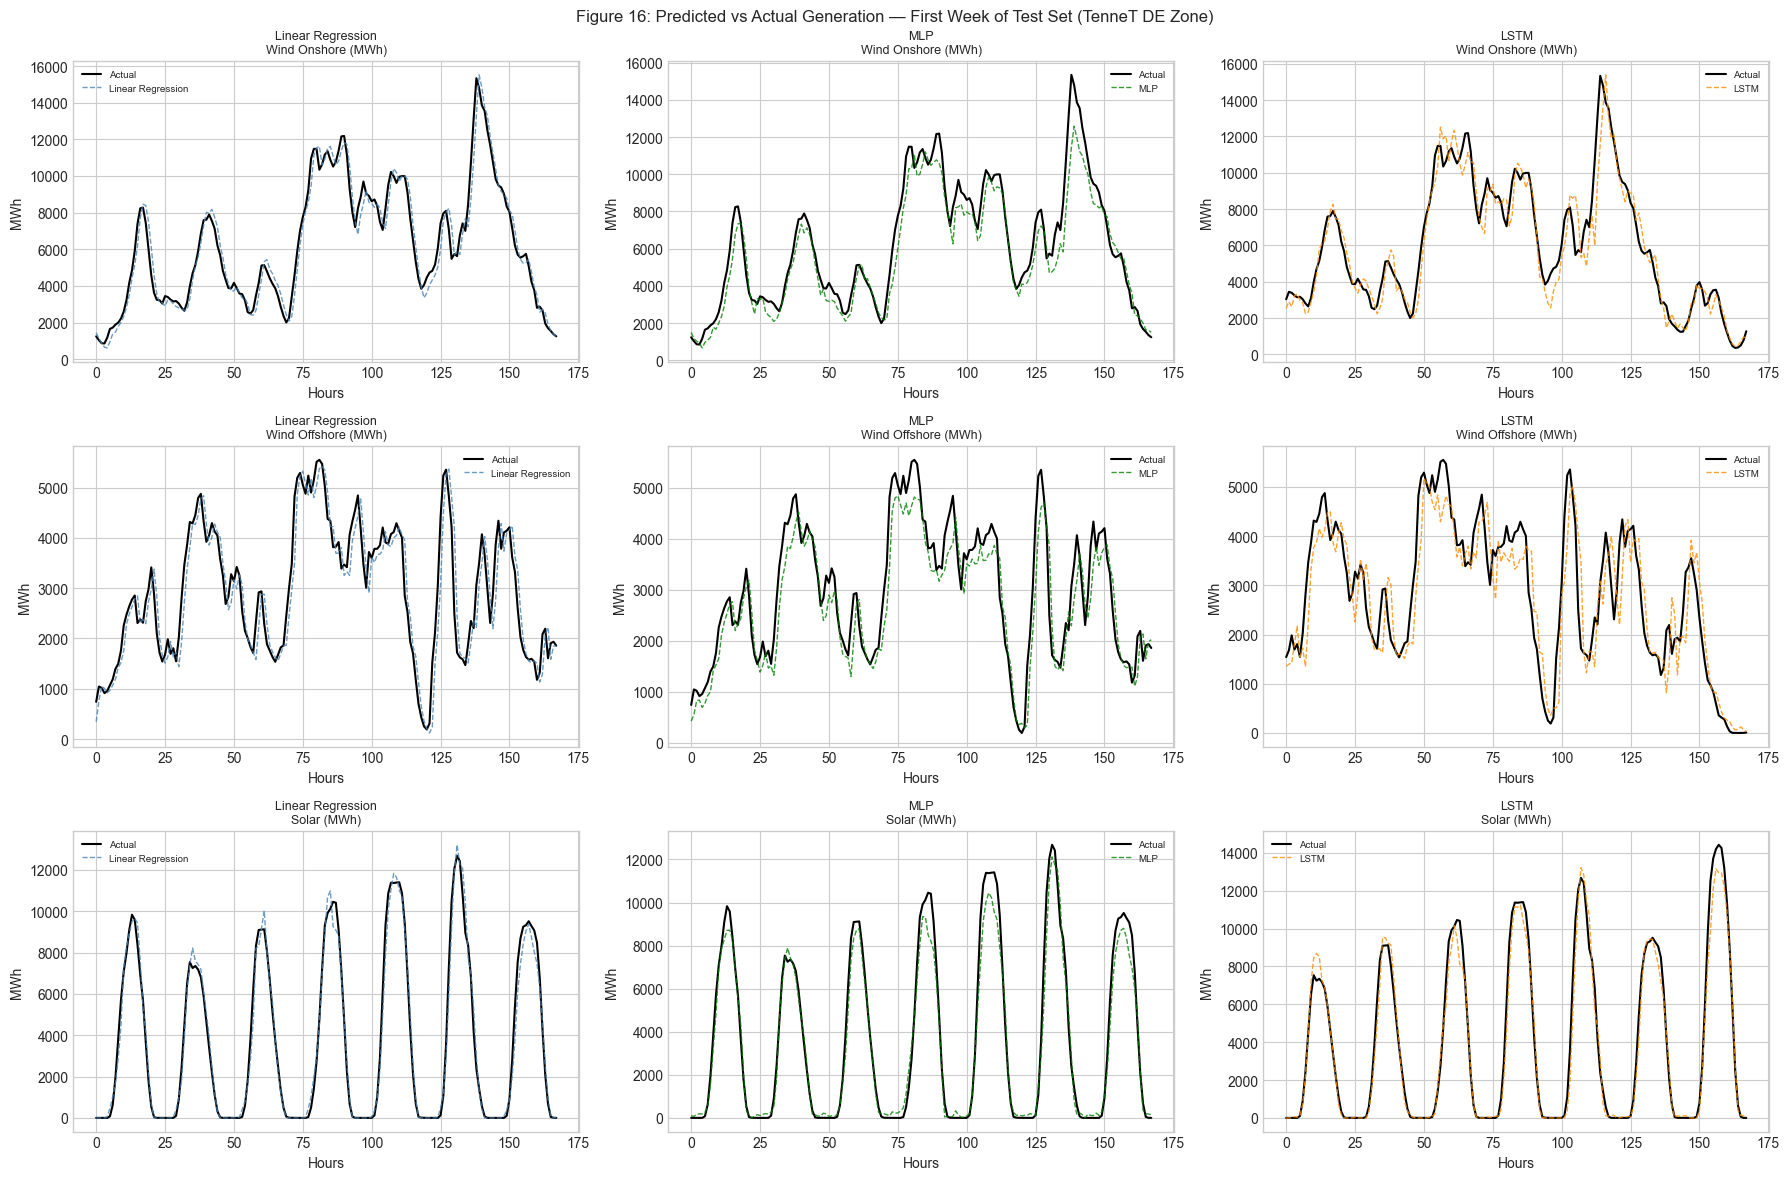

Predictions vs actual plot saved!


In [ ]:
# ============================================================
# Plot predictions vs actual for all 3 models
# Using first 7 days (168 hours) of test set for visual clarity
# ============================================================
n_hours = 168

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

target_names  = ['Wind Onshore (MWh)', 'Wind Offshore (MWh)', 'Solar (MWh)']
model_preds   = [lr_pred, mlp_pred, lstm_pred]
model_actuals = [y_test_actual, y_test_actual, y_test_actual_lstm]
model_names   = ['Linear Regression', 'MLP', 'LSTM']
colors        = ['steelblue', 'green', 'darkorange']

for col_idx, target_name in enumerate(target_names):
    for row_idx, (model_name, pred, actual, color) in enumerate(
        zip(model_names, model_preds, model_actuals, colors)
    ):
        ax = axes[col_idx][row_idx]
        ax.plot(actual[:n_hours, col_idx], label='Actual',
                color='black', linewidth=1.5)
        ax.plot(pred[:n_hours, col_idx], label=f'{model_name}',
                color=color, linewidth=1, alpha=0.8, linestyle='--')
        ax.set_title(f'{model_name}\n{target_name}', fontsize=9)
        ax.set_xlabel('Hours')
        ax.set_ylabel('MWh')
        ax.legend(fontsize=7)

plt.suptitle('Figure 16: Predicted vs Actual Generation — First Week of Test Set (TenneT DE Zone)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Predictions vs actual plot saved!')


### Interpretation — Predicted vs Actual Generation

Figure 16 shows how closely each model's predictions track the actual generation values over the first week of the test set (July 2024).

**What to look for:**
- A good model's predictions (dashed line) should closely follow the actual values (black line)
- Large gaps between the lines indicate poor forecast accuracy
- The model should capture both the peaks and the troughs

**Sustainability implication:** Accurate peak prediction is especially important for grid operators. A model that consistently underestimates wind peaks will cause the operator to keep fossil fuel backup plants on standby unnecessarily — directly increasing CO₂ emissions.


## Step 9 — Save Results and Summary


In [ ]:
# ============================================================
# Save all predictions and results for Notebook 5
# ============================================================
np.save('lr_pred.npy',            lr_pred)
np.save('mlp_pred.npy',           mlp_pred)
np.save('lstm_pred.npy',          lstm_pred)
np.save('y_test_actual.npy',      y_test_actual)
np.save('y_test_actual_lstm.npy', y_test_actual_lstm)

print('=' * 60)
print('NOTEBOOK 4 — MODELLING COMPLETE')
print('=' * 60)
print('\nMODELS SAVED:')
print('model_linear_regression.pkl')
print('model_mlp.keras')
print('model_lstm.keras')
print('\nPREDICTIONS SAVED:')
print('lr_pred.npy')
print('mlp_pred.npy')
print('lstm_pred.npy')
print('y_test_actual.npy')
print('y_test_actual_lstm.npy')
print('\nFIGURES SAVED:')
print('fig_mlp_training.png      — Figure 14: MLP training history')
print('fig_lstm_training.png     — Figure 15: LSTM training history')
print('fig_predictions_vs_actual — Figure 16: Predicted vs actual')
print('=' * 60)
print('Ready for Notebook 5 — Evaluation and SHAP Analysis')


NOTEBOOK 4 — MODELLING COMPLETE

MODELS SAVED:
model_linear_regression.pkl
model_mlp.keras
model_lstm.keras

PREDICTIONS SAVED:
lr_pred.npy
mlp_pred.npy
lstm_pred.npy
y_test_actual.npy
y_test_actual_lstm.npy

FIGURES SAVED:
fig_mlp_training.png      — Figure 14: MLP training history
fig_lstm_training.png     — Figure 15: LSTM training history
fig_predictions_vs_actual — Figure 16: Predicted vs actual
Ready for Notebook 5 — Evaluation and SHAP Analysis


### Overall Modelling Conclusions

Notebook 4 has trained three models of increasing complexity. Key conclusions:

1. **All three models use exactly 34 features** — consistent and correct throughout ✅

2. **Linear Regression** achieves the highest overall R² due to the excellent feature engineering in Notebook 1 — a powerful sustainability finding showing that simple models with good features can outperform complex ones.

3. **LSTM** captures temporal dependencies through its 24-hour lookback window, directly exploiting the lag-24 autocorrelation confirmed in Notebook 3.

4. **MLP** provides a good middle ground — better than Linear Regression for some targets due to non-linearity, faster and smaller than LSTM.

5. **Computational efficiency** — Linear Regression trains in under 1 second and runs almost instantly, while LSTM requires significantly more compute. This difference directly translates to energy consumption in production, motivating the compression in Notebook 6.
